In [1]:
#The original file

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


# Open as a memory-mapped array (read-only)
df = np.load("C:/DCU_final_year_project/ItoQUVcorrected_CBJTML_hairlinefree_contnorm_630only.npy", mmap_mode="r")

In [2]:
df.shape

#4 is Stokes I,Q,U,V
#182 is the wavelength dimension 
#|| 2555 is the y direction which is along the slit of instrument)
#900 is the scanning direction, x direction, temporal domain as instrument is scanned


(4, 182, 2555, 900)

In [4]:
#Code used to check sign of Stokes V profile
#It flipped

#v_sign_check = df[3,:, :, :]
#max_positive = np.max(v_sign_check, axis=0)
#max_negative = np.min(v_sign_check, axis=0)

#flip = np.abs(max_negative) > np.abs(max_positive)

#v_sign_check[:, flip] *= -1
#df[3,:, :, :] = v_sign_check

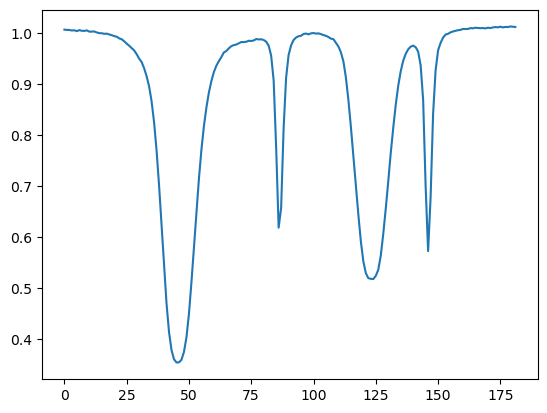

In [13]:
plt.plot(df[0, :, 300, 100])
plt.show()

#just plot stokes IQUV (depending on value of first parameter in array) for 1 pixel of all the wavelengths

In [6]:
np.average(peaks, axis=0)


NameError: name 'peaks' is not defined

In [ ]:
#import numpy as np
#from scipy.signal import find_peaks

# Create a signal with some peaks
#signal = np.array([1, 2, 3, 4, 5, 4, 3, 2, 1])

# Find the peaks in the signal
#peaks, _ = find_peaks(signal)

#I_dips = df[0, :, :, :]

#dips, _ = find_peaks(I_dips)

# Print the indices of the peaks
#print(peaks)

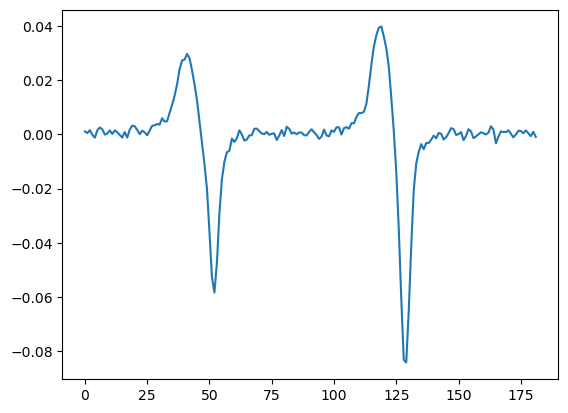

(4, 182, 2555, 900)

In [4]:
plt.plot(df[3, :, 1600, 100])
plt.show()
df.shape



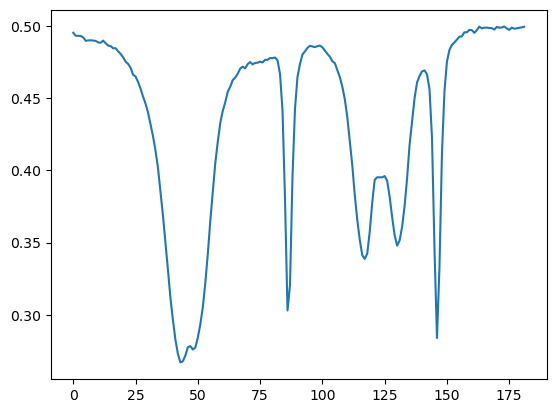

In [13]:
plt.plot(df[0, :, 1300, 100])
plt.show()

In [36]:
df.shape

(4, 182, 2555, 900)

In [37]:
arr.shape

(4, 0, 2555, 900)

In [39]:
region_of_interest = df[0, :, 700:1700, :]
#region_of_interest.shape

arr = region_of_interest
reshaped_array = np.moveaxis(arr, 0, -1).reshape(-1, 182)

test = np.moveaxis(arr, 0, -1)
test.shape


(1000, 900, 182)

In [52]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

import sunpy.visualization.colormaps as cm

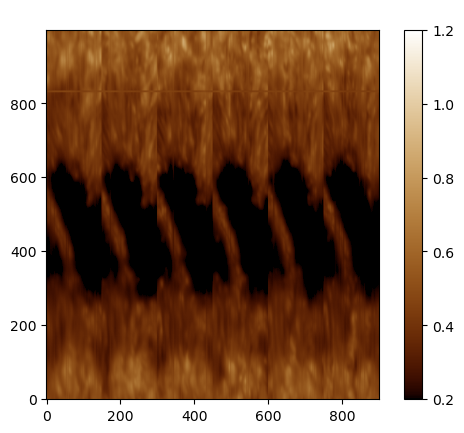

In [66]:
plt.title(f"Class 61 locations 67% of pixels)", color = 'white')
plt.imshow(arr[50, :, :], origin = 'lower', cmap = 'sdoaia193', vmin = 0.2, vmax = 1.2) # can 
plt.colorbar()
plt.show()
#for df plot V at wavelength 50 for all pixels

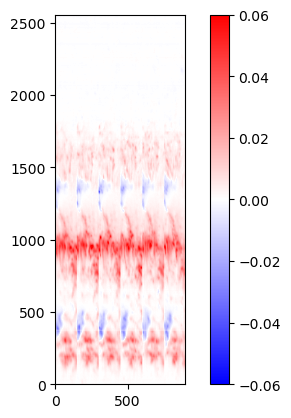

In [36]:
plt.imshow(df[1, 50, :, :], origin = 'lower', cmap = 'bwr', vmin = -0.06, vmax = 0.06) # can 
plt.colorbar()
plt.show()
#for df plot Q at wavelength 50 for all pixels

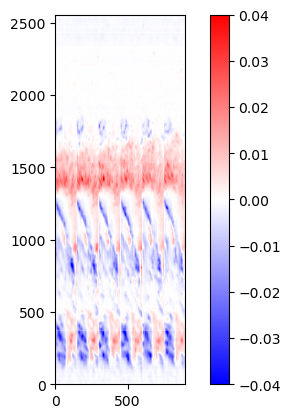

In [39]:
plt.imshow(df[1, 50, :, :], origin = 'lower', cmap = 'bwr', vmin = -0.04, vmax = 0.04) # can 
plt.colorbar()
plt.show()
#for df plot U at wavelength 50 for all pixels

In [ ]:
#Need to develop a function to multiply a profile by -1 if its minimum value has
# a larger negative amplitude than the maximum value's positive amplitude

#We need to do this to avoid kmeans grouping clusters based on polarity



In [16]:
#Create a function to work out the optimum number of clusters
#Need to get a 2D array for this

def optimise_k_means(data, max_k):
    means = []
    inertias = []
    
    for k in range(1, max_k):
        kmeans = KMeans(n_clusters = k)
        kmeans.fit(data)
        
        means.append(k)
        inertias.append(kmeans.inertia_)
        
        #Generate elbow plot
        fig = plt.subplots(figsize(10, 5))
        plt.plot(means, inertias, 'o-')
        plt.xlabel('Number of Clusters')
        plt.ylabel('Inertia')
        plt.grid(True)
        plt.show()

In [17]:
#cannot use kmeans on the 4D array, need to preprocess and clean data
#optimise_k_means(df, 10)

ValueError: Found array with dim 4. Estimator expected <= 2.